# Limpieza y transformación de datos: FIFA 21

## Objetivo del notebook
Este notebook documenta un flujo completo y reproducible de limpieza, transformación y validación del dataset **FIFA 21**.  
El objetivo es transformar un archivo crudo en un conjunto de datos más limpio, consistente y preparado para etapas posteriores de análisis o modelado.

## Alcance del trabajo
A partir de los archivos entregados para el proyecto, en este notebook se realiza:

- carga del dataset original;
- exploración inicial de su estructura;
- revisión de nulos y duplicados;
- limpieza modular de variables en formato monetario y físico;
- creación de nuevas variables derivadas del contrato;
- validación antes y después de la limpieza;
- transformación con `Pipeline` y `ColumnTransformer`;
- guardado del archivo procesado.

> Todas las decisiones documentadas aquí se basan únicamente en los archivos entregados para este proyecto.


In [1]:
from pathlib import Path
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# -------------------------------------------------------------------
# Búsqueda robusta de rutas para que el notebook funcione en Colab,
# Jupyter local o dentro del repositorio de GitHub.
# -------------------------------------------------------------------
possible_roots = [
    Path.cwd(),
    Path.cwd() / "evparcial1",
    Path("/content/evparcial1"),
    Path("/content"),
    Path("/mnt/data")
]

root = None
for candidate in possible_roots:
    if candidate.exists():
        if (candidate / "data" / "fifa21_raw_data.csv").exists() or (candidate / "fifa21_raw_data.csv").exists():
            root = candidate
            break

if root is None:
    raise FileNotFoundError("No se encontró la raíz del proyecto ni el archivo fifa21_raw_data.csv")

# Posibles ubicaciones de datos y módulo de funciones
raw_candidates = [
    root / "data" / "fifa21_raw_data.csv",
    root / "fifa21_raw_data.csv"
]
processed_output = root / "data" / "fifa21_processed.csv" if (root / "data").exists() else root / "fifa21_processed.csv"

src_candidates = [
    root / "src",
    root / "evparcial1" / "src"
]

raw_path = next((p for p in raw_candidates if p.exists()), None)
if raw_path is None:
    raise FileNotFoundError("No se encontró el archivo fifa21_raw_data.csv")

for src_path in src_candidates:
    if src_path.exists():
        sys.path.append(str(src_path))

print(f"Ruta base detectada: {root}")
print(f"Archivo crudo detectado: {raw_path}")
print(f"Archivo procesado se guardará en: {processed_output}")


Ruta base detectada: /content
Archivo crudo detectado: /content/fifa21_raw_data.csv
Archivo procesado se guardará en: /content/fifa21_processed.csv


## 1. Carga del dataset y exploración inicial

Primero se carga el archivo original para conocer su tamaño, tipos de datos y estructura general.  
Esta etapa permite detectar desde el inicio posibles problemas de calidad, como columnas con formatos inconsistentes, valores faltantes o duplicados.


In [2]:
# Carga del dataset original
df_raw = pd.read_csv(raw_path, low_memory=False)

print("Dimensiones del dataset original:")
print(df_raw.shape)

print("\nPrimeras filas:")
display(df_raw.head())

print("\nInformación general:")
df_raw.info()


Dimensiones del dataset original:
(18979, 77)

Primeras filas:


,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,ID,Height,Weight,foot,BOV,BP,Growth,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,158023,"5'7""",159lbs,Left,93,RW,0,"Jul 1, 2004",NaN,€67.5M,€560K,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,20801,"6'2""",183lbs,Right,92,ST,0,"Jul 10, 2018",NaN,€46M,€220K,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,200389,"6'2""",192lbs,Right,91,GK,2,"Jul 16, 2014",NaN,€75M,€125K,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,192985,"5'11""",154lbs,Right,91,CAM,0,"Aug 30, 2015",NaN,€87M,€370K,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,190871,"5'9""",150lbs,Right,91,LW,0,"Aug 3, 2017",NaN,€90M,€270K,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,\n273



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   photoUrl          18979 non-null  object
 1   LongName          18979 non-null  object
 2   playerUrl         18979 non-null  object
 3   Nationality       18979 non-null  object
 4   Positions         18979 non-null  object
 5   Name              18979 non-null  object
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Team & Contract   18979 non-null  object
 10  ID                18979 non-null  int64 
 11  Height            18979 non-null  object
 12  Weight            18979 non-null  object
 13  foot              18979 non-null  object
 14  BOV               18979 non-null  int64 
 15  BP                18979 non-null  object
 16  Growth            18979 non-null  in

### Observaciones iniciales

Con la carga del archivo original se observa que el dataset contiene información de jugadores, métricas deportivas, datos físicos y variables económicas.  
También se aprecia que existen columnas en formatos no directamente utilizables para modelado, por ejemplo:

- `Value` y `Wage`, que vienen con símbolos monetarios y sufijos como `M` y `K`;
- `Height` y `Weight`, que vienen en formatos físicos no homogéneos;
- `Team & Contract`, que contiene información compuesta en una sola columna;
- `Loan Date End`, que presenta valores faltantes en gran parte de los registros.

Estas condiciones justifican la necesidad de una etapa formal de limpieza y transformación.


In [3]:
# Revisión de nulos y duplicados
null_summary = df_raw.isna().sum().sort_values(ascending=False)
null_summary = null_summary[null_summary > 0].to_frame(name="nulos")
null_summary["porcentaje"] = (null_summary["nulos"] / len(df_raw) * 100).round(2)

duplicados = int(df_raw.duplicated().sum())

print("Columnas con nulos:")
display(null_summary)

print(f"Cantidad de filas duplicadas exactas: {duplicados}")


Columnas con nulos:


,nulos,porcentaje
Loan Date End,17966,94.66


Cantidad de filas duplicadas exactas: 1


## 2. Validación inicial de calidad de datos

La revisión inicial muestra dos puntos relevantes:

1. **Valores nulos**: la columna `Loan Date End` concentra la mayor cantidad de valores faltantes. Esto es coherente con el contexto del dataset, ya que no todos los jugadores están a préstamo.
2. **Duplicados**: existe al menos un registro duplicado exacto, por lo que conviene eliminar duplicados para evitar sesgos o conteos repetidos en análisis posteriores.

En esta etapa no se eliminan filas por los nulos de `Loan Date End`, porque esos valores faltantes pueden ser estructurales y no necesariamente errores.


## 3. Importación de funciones modulares de limpieza

Siguiendo buenas prácticas de desarrollo, las funciones de limpieza se separan en un módulo externo (`src/limpieza_funciones.py`).  
Esto mejora la organización del proyecto, favorece la reutilización del código y hace más fácil mantener el notebook.

Las funciones utilizadas son:

- `limpiar_dinero()`: convierte montos como `€67.5M` o `€560K` a números flotantes;
- `limpiar_altura()`: normaliza alturas en centímetros;
- `limpiar_peso()`: normaliza pesos en kilogramos.


In [4]:
# Se intenta importar el módulo externo con las funciones de limpieza.
# Si el entorno no lo encuentra, se definen aquí como respaldo para que
# el notebook siga siendo ejecutable.

try:
    from limpieza_funciones import limpiar_dinero, limpiar_altura, limpiar_peso
    print("Funciones de limpieza importadas correctamente desde src/limpieza_funciones.py")
except Exception as e:
    print(f"No fue posible importar el módulo externo ({e}). Se usarán funciones de respaldo.")

    def limpiar_dinero(valor):
        """
        Convierte strings de moneda (ej: €110.5M) a valores numéricos flotantes.
        Elimina el símbolo de Euro y multiplica según sufijos K (miles) o M (millones).
        """
        if valor is None:
            return 0.0

        if isinstance(valor, str):
            valor = valor.replace('€', '').strip()

            try:
                if 'M' in valor:
                    return float(valor.replace('M', '')) * 1_000_000
                elif 'K' in valor:
                    return float(valor.replace('K', '')) * 1_000
                else:
                    return float(valor)
            except ValueError:
                return 0.0

        return float(valor)

    def limpiar_altura(valor):
        """
        Normaliza la altura a centímetros.
        Maneja tanto el formato métrico (180cm) como el imperial (5'11").
        """
        if valor is None:
            return 0.0

        valor = str(valor).strip()

        try:
            if "'" in valor:
                pies, pulgadas = valor.split("'")
                pulgadas = pulgadas.replace('"', '')
                return round((int(pies) * 30.48) + (int(pulgadas) * 2.54), 1)

            return float(valor.replace('cm', ''))

        except ValueError:
            return 0.0

    def limpiar_peso(valor):
        """
        Normaliza el peso a kilogramos.
        Maneja tanto kg como lbs (libras).
        """
        if valor is None:
            return 0.0

        valor = str(valor).strip()

        try:
            if 'lbs' in valor:
                return round(float(valor.replace('lbs', '')) * 0.453592, 1)

            return float(valor.replace('kg', ''))

        except ValueError:
            return 0.0


No fue posible importar el módulo externo (No module named 'limpieza_funciones'). Se usarán funciones de respaldo.


In [5]:
# Muestra antes de limpiar
columnas_revision = ["Value", "Wage", "Height", "Weight", "Team & Contract", "Loan Date End"]
print("Ejemplo de valores originales:")
display(df_raw[columnas_revision].head())


Ejemplo de valores originales:


,Value,Wage,Height,Weight,Team & Contract,Loan Date End
0,€67.5M,€560K,"5'7""",159lbs,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,NaN
1,€46M,€220K,"6'2""",183lbs,\n\n\n\nJuventus\n2018 ~ 2022\n\n,NaN
2,€75M,€125K,"6'2""",192lbs,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,NaN
3,€87M,€370K,"5'11""",154lbs,\n\n\n\nManchester City\n2015 ~ 2023\n\n,NaN
4,€90M,€270K,"5'9""",150lbs,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,NaN


## 4. Limpieza de variables con formato no numérico

Se crea una copia del dataset original para trabajar sin alterar el archivo cargado inicialmente.  
Luego se aplican funciones modulares a las variables que requieren normalización.

### Decisiones de limpieza aplicadas
- `Value` y `Wage`: se convierten desde texto monetario a formato numérico.
- `Height`: se transforma a centímetros.
- `Weight`: se transforma a kilogramos.
- se eliminan filas duplicadas exactas para evitar redundancia en el análisis.


In [6]:
df = df_raw.copy()

# Limpieza de variables económicas y físicas
df["Value"] = df["Value"].apply(limpiar_dinero)
df["Wage"] = df["Wage"].apply(limpiar_dinero)
df["Height"] = df["Height"].apply(limpiar_altura)
df["Weight"] = df["Weight"].apply(limpiar_peso)

# Eliminación de duplicados exactos
duplicados_antes = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
duplicados_despues = int(df.duplicated().sum())

print(f"Duplicados antes: {duplicados_antes}")
print(f"Duplicados después: {duplicados_despues}")

print("\nEjemplo después de la limpieza:")
display(df[["Value", "Wage", "Height", "Weight"]].head())


Duplicados antes: 1
Duplicados después: 0

Ejemplo después de la limpieza:


,Value,Wage,Height,Weight
0,"67,500,000.00","560,000.00",170.20,72.10
1,"46,000,000.00","220,000.00",188.00,83.00
2,"75,000,000.00","125,000.00",188.00,87.10
3,"87,000,000.00","370,000.00",180.30,69.90
4,"90,000,000.00","270,000.00",175.30,68.00


### Justificación técnica

Estas transformaciones son necesarias porque los algoritmos de análisis y modelado no trabajan de forma directa con expresiones como `€67.5M`, `5'7"` o `159lbs`.  
La conversión a valores numéricos mejora la consistencia del dataset y permite:

- calcular estadísticas descriptivas reales;
- aplicar escalamiento;
- usar pipelines de preprocesamiento;
- comparar registros bajo una misma unidad de medida.


## 5. Ingeniería de variables: contrato y años restantes

La columna `Team & Contract` contiene más de una pieza de información dentro de un mismo campo.  
Para hacerla más útil, se generan dos variables derivadas:

- `Contract_End`: año detectado al final del contrato;
- `Years_Left`: diferencia entre el año de término del contrato y el año base **2021**, que es coherente con el contexto del dataset FIFA 21.

Cuando no es posible identificar un año de término, el valor queda como nulo.


In [7]:
def extraer_fin_contrato(texto):
    """
    Extrae el último año de cuatro dígitos encontrado en la columna
    'Team & Contract'. Si no encuentra un año, retorna NaN.
    """
    texto = str(texto)
    coincidencias = re.findall(r"(19\d{2}|20\d{2})", texto)
    if coincidencias:
        return float(coincidencias[-1])
    return np.nan

df["Contract_End"] = df["Team & Contract"].apply(extraer_fin_contrato)
df["Years_Left"] = df["Contract_End"] - 2021

display(df[["Team & Contract", "Contract_End", "Years_Left"]].head(10))


,Team & Contract,Contract_End,Years_Left
0,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,"2,021.00",0.00
1,\n\n\n\nJuventus\n2018 ~ 2022\n\n,"2,022.00",1.00
2,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,"2,023.00",2.00
3,\n\n\n\nManchester City\n2015 ~ 2023\n\n,"2,023.00",2.00
4,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,"2,022.00",1.00
5,\n\n\n\nFC Bayern München\n2014 ~ 2023\n\n,"2,023.00",2.00
6,\n\n\n\nParis Saint-Germain\n2018 ~ 2022\n\n,"2,022.00",1.00
7,\n\n\n\nLiverpool\n2018 ~ 2024\n\n,"2,024.00",3.00
8,\n\n\n\nLiverpool\n2017 ~ 2023\n\n,"2,023.00",2.00
9,\n\n\n\nLiverpool\n2016 ~ 2023\n\n,"2,023.00",2.00


## 6. Validación posterior a la limpieza

Después de limpiar y transformar las variables, se vuelve a revisar el dataset para comprobar:

- si las columnas transformadas quedaron en formato numérico;
- si los duplicados fueron eliminados;
- cómo quedaron los nulos luego de la ingeniería de variables.


In [8]:
print("Tipos de datos de columnas clave:")
display(df[["Value", "Wage", "Height", "Weight", "Contract_End", "Years_Left"]].dtypes)

null_summary_clean = df.isna().sum().sort_values(ascending=False)
null_summary_clean = null_summary_clean[null_summary_clean > 0].to_frame(name="nulos")
null_summary_clean["porcentaje"] = (null_summary_clean["nulos"] / len(df) * 100).round(2)

print("\nColumnas con nulos después de la limpieza:")
display(null_summary_clean.head(10))

print(f"\nDimensiones después de eliminar duplicados: {df.shape}")


Tipos de datos de columnas clave:


,0
Value,float64
Wage,float64
Height,float64
Weight,float64
Contract_End,float64
Years_Left,float64



Columnas con nulos después de la limpieza:


,nulos,porcentaje
Loan Date End,17965,94.66
Contract_End,237,1.25
Years_Left,237,1.25



Dimensiones después de eliminar duplicados: (18978, 79)


### Interpretación de la validación

La validación confirma que las columnas económicas y físicas intervenidas ya se encuentran en formato numérico.  
También se verifica que los duplicados exactos fueron removidos.

Respecto a los valores faltantes, `Loan Date End` sigue concentrando una gran cantidad de nulos, lo que se interpreta como una característica estructural del dataset y no necesariamente como un error.  
Además, algunas filas pueden quedar sin `Contract_End` o `Years_Left` cuando la cadena original no contiene un año de término explícito.


## 7. Estadísticas descriptivas y visualización básica

Para respaldar el análisis exploratorio, se revisan estadísticas de algunas variables clave y se generan visualizaciones simples que ayudan a comunicar el resultado del procesamiento.


In [9]:
resumen_numerico = df[["Age", "Value", "Wage", "Height", "Weight", "Years_Left"]].describe().T
display(resumen_numerico)


,count,mean,std,min,25%,50%,75%,max
Age,"18,978.00",25.19,4.71,16.00,21.00,25.00,29.00,53.00
Value,"18,978.00","2,229,070.66","5,097,723.06",0.00,"300,000.00","650,000.00","1,800,000.00","105,500,000.00"
Wage,"18,978.00","8,796.59","19,537.69",0.00,"1,000.00","3,000.00","8,000.00","560,000.00"
Height,"18,978.00",181.23,6.82,154.90,175.30,180.30,185.40,205.70
Weight,"18,978.00",75.01,7.07,49.90,69.90,74.80,79.80,110.20
Years_Left,"18,741.00",1.00,1.27,-1.00,0.00,1.00,2.00,7.00


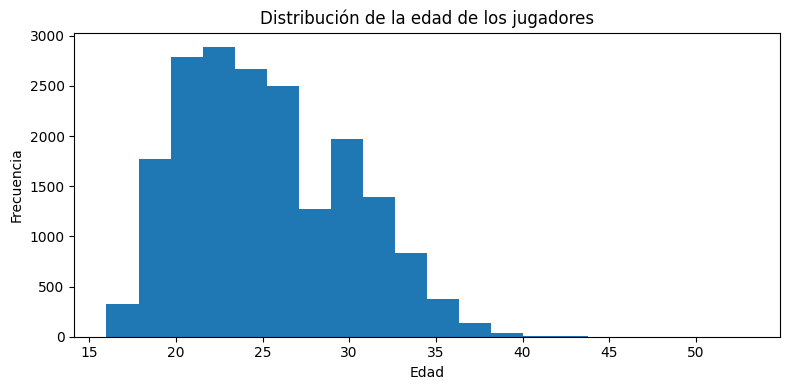

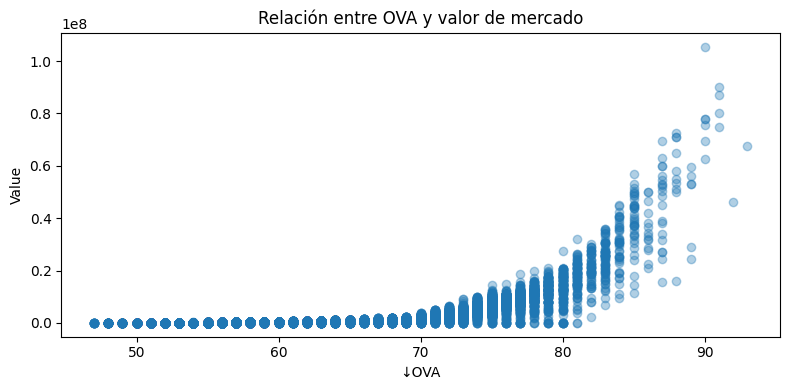

In [10]:
# Distribución de edad
plt.figure(figsize=(8, 4))
plt.hist(df["Age"], bins=20)
plt.title("Distribución de la edad de los jugadores")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Relación entre valoración general y valor de mercado
plt.figure(figsize=(8, 4))
plt.scatter(df["↓OVA"], df["Value"], alpha=0.35)
plt.title("Relación entre OVA y valor de mercado")
plt.xlabel("↓OVA")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


### Interpretación breve de los gráficos

- La distribución de edad permite identificar el rango etario predominante del dataset.
- El gráfico de dispersión entre `↓OVA` y `Value` ayuda a observar si existe una tendencia general entre la valoración del jugador y su valor de mercado.

Estas visualizaciones son simples, pero útiles para complementar el análisis exploratorio inicial exigido en la evaluación.


## 8. Transformación con Pipeline

Como parte del flujo profesional de preprocesamiento, se construye un `Pipeline` para preparar un subconjunto de variables numéricas y categóricas.

### Variables seleccionadas
- **Numéricas**: `Age`, `↓OVA`, `Height`, `Value`, `Wage`
- **Categóricas**: `foot`, `BP`

### Procesos aplicados
- En variables numéricas:
  - imputación por media;
  - escalamiento con `StandardScaler`.
- En variables categóricas:
  - imputación por moda;
  - codificación con `OneHotEncoder`.

Este enfoque permite dejar el proceso listo para una futura etapa de modelado.


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cols_numericas = ["Age", "↓OVA", "Height", "Value", "Wage"]
cols_categoricas = ["foot", "BP"]

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(transformers=[
    ("num", num_pipeline, cols_numericas),
    ("cat", cat_pipeline, cols_categoricas)
])

datos_listos = preprocesador.fit_transform(df)

print("Pipeline ejecutado correctamente.")
print(f"Forma de la matriz transformada: {datos_listos.shape}")
print(f"Tipo de salida: {type(datos_listos)}")


Pipeline ejecutado correctamente.
Forma de la matriz transformada: (18978, 22)
Tipo de salida: <class 'numpy.ndarray'>


### Justificación técnica del pipeline

El uso de `Pipeline` y `ColumnTransformer` mejora la reproducibilidad del proyecto porque concentra en una sola estructura todas las transformaciones necesarias.  
Además, evita aplicar pasos manuales por separado, reduce errores y deja el preprocesamiento listo para integrarse con modelos de machine learning en etapas posteriores.


## 9. Guardado del archivo procesado

Finalmente, se exporta el dataset limpio y transformado para dejar una versión lista para compartir dentro del proyecto.


In [12]:
# Se intenta guardar en la ruta principal del proyecto.
# Si esa ruta no permite escritura, se crea una copia alternativa.

try:
    df.to_csv(processed_output, index=False)
    saved_path = processed_output
except PermissionError:
    saved_path = processed_output.with_name(f"{processed_output.stem}_nuevo.csv")
    df.to_csv(saved_path, index=False)

print("Archivo procesado guardado correctamente.")
print(saved_path)


Archivo procesado guardado correctamente.
/content/fifa21_processed.csv


## 10. Conclusiones

A partir del dataset original de FIFA 21 se construyó un flujo de trabajo reproducible que incluye exploración, limpieza, validación, ingeniería de variables y transformación con pipeline.

### Resultados principales
- se normalizaron variables monetarias y físicas a formato numérico;
- se eliminaron registros duplicados exactos;
- se crearon las variables `Contract_End` y `Years_Left`;
- se documentó un pipeline de transformación para variables numéricas y categóricas;
- se generó un archivo procesado listo para futuras etapas de análisis o modelado.

### Reflexión final
El trabajo muestra cómo un dataset aparentemente utilizable puede requerir varios ajustes antes de ser realmente apto para análisis técnico.  
La modularidad del código, la validación antes y después de limpiar, y la automatización con pipeline fortalecen la calidad del proyecto y su reproducibilidad.
